<a href="https://colab.research.google.com/github/hsyyan91/TIMSS2023_Math/blob/main/Manuscript_TIMSS2023_4_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# 0. Imports
# =============================================================================
!pip install pyreadstat
import pandas as pd
import numpy as np
import pyreadstat
import lightgbm as lgb
import statistics
from scipy import stats
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# =============================================================================
# 1. Load data
# =============================================================================
df, meta = pyreadstat.read_sav("spss_merged_grade4_student.sav")
df.shape
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.4 MB/s eta 0:00:00


,IDCNTRY,IDPOP,IDGRADER,IDGRADE,ITASSESS,IDBOOK,IDSCHOOL,IDCLASS,IDSTUD,ITSEX,...,ASDHLNT,ASBHPSP,ASDHPSP,ASBHSES,ASDHSES,ASDHOCCP,ASDHEDUP,ASDHAPS,VERSION,SCOPE
0,702.0,1.0,1.0,4.0,1.0,11.0,5001.0,500101.0,50010101.0,1.0,...,2.0,9.20420,2.0,9.07087,2.0,3.0,2.0,4.0,4.0,1.0
1,702.0,1.0,1.0,4.0,1.0,5.0,5001.0,500101.0,50010102.0,2.0,...,2.0,6.06211,3.0,8.64527,3.0,3.0,3.0,1.0,4.0,1.0
2,702.0,1.0,1.0,4.0,1.0,1.0,5001.0,500101.0,50010105.0,2.0,...,1.0,NaN,NaN,11.16910,1.0,1.0,2.0,4.0,4.0,1.0
3,702.0,1.0,1.0,4.0,1.0,2.0,5001.0,500101.0,50010106.0,2.0,...,2.0,6.92191,2.0,9.76546,2.0,1.0,3.0,2.0,4.0,1.0
4,702.0,1.0,1.0,4.0,1.0,3.0,5001.0,500101.0,50010107.0,1.0,...,2.0,12.18163,1.0,10.77427,2.0,1.0,2.0,4.0,4.0,1.0


In [2]:
# =============================================================================
# 2. Define variables
# =============================================================================

# Linguistic variables
linguistic_vars = [
    "ITLANG_HQ", "LCID_HQ",
    "ASBHELA", "ASDHELA",
    "ASBHENA", "ASDHENA",
    "ASBHELN", "ASDHELN",
    "ASBHELT", "ASDHELT",
    "ASBHENT", "ASDHENT",
    "ASBHLNT", "ASDHLNT",
    "ASBHPSP", "ASDHPSP",
]

# Capital variables
# I have deleted ASBH20, ASBH19, ASBH14GB, ASBH14GA, ASBH02B because they have more than 50% missing values
capital_vars = [
    "ASBH01A","ASBH01B","ASBH01C","ASBH01D","ASBH01E","ASBH01F","ASBH01G",
    "ASBH01H","ASBH01I","ASBH01J","ASBH01K","ASBH01L","ASBH01M","ASBH01N",
    "ASBH01O","ASBH01P","ASBH01Q","ASBH01R",
    "ASBH02A",
    "ASBH03A","ASBH03B","ASBH03C","ASBH03D","ASBH03E","ASBH03F",
    "ASBH04AA","ASBH04AB","ASBH04B",
    "ASBH05",
    "ASBH06A","ASBH06B","ASBH06C","ASBH06D","ASBH06E","ASBH06F","ASBH06G",
    "ASBH07A","ASBH07B","ASBH07C","ASBH07D","ASBH07E",
    "ASBH08A","ASBH08B","ASBH08C","ASBH08D","ASBH08E","ASBH08F","ASBH08G","ASBH08H",
    "ASBH09A","ASBH09B","ASBH09C","ASBH09D","ASBH09E",
    "ASBH10","ASBH11",
    "ASBH12A","ASBH12B","ASBH12C",
    "ASBH13A","ASBH13B",
    "ASBH14AA","ASBH14AB","ASBH14BA","ASBH14BB",
    "ASBH14CA","ASBH14CB",
    "ASBH14DA","ASBH14DB",
    "ASBH14EA","ASBH14EB",
    "ASBH14FA","ASBH14FB",
    "ASBH15",
    "ASBH16A","ASBH16B",
    "ASBH17",
    "ASBH18A","ASBH18B",
    "ASBHSES","ASDHSES",
    "ASDHOCCP",
    "ASDHEDUP",
    "ASDHAPS",
]
features_numeric = ["ITLANG_HQ", "LCID_HQ", "ASBHELA", "ASBHELT", "ASBHENA", "ASBHENT", "ASBHLNT", "ASBHPSP", "ASBHSES", "ASBHELN"]
features_categorical = ["ASBH01A", "ASBH01B","ASBH01C","ASBH01D","ASBH01E","ASBH01F","ASBH01G",
    "ASBH01H","ASBH01I","ASBH01J","ASBH01K","ASBH01L","ASBH01M","ASBH01N",
    "ASBH01O","ASBH01P","ASBH01Q","ASBH01R",
    "ASBH02A",
    "ASBH03A","ASBH03B","ASBH03C","ASBH03D","ASBH03E","ASBH03F",
    "ASBH04AA","ASBH04AB","ASBH04B",
    "ASBH05",
    "ASBH06A","ASBH06B","ASBH06C","ASBH06D","ASBH06E","ASBH06F","ASBH06G",
    "ASBH07A","ASBH07B","ASBH07C","ASBH07D","ASBH07E",
    "ASBH08A","ASBH08B","ASBH08C","ASBH08D","ASBH08E","ASBH08F","ASBH08G","ASBH08H",
    "ASBH09A","ASBH09B","ASBH09C","ASBH09D","ASBH09E",
    "ASBH10","ASBH11",
    "ASBH12A","ASBH12B","ASBH12C",
    "ASBH13A","ASBH13B",
    "ASBH14AA","ASBH14AB","ASBH14BA","ASBH14BB",
    "ASBH14CA","ASBH14CB",
    "ASBH14DA","ASBH14DB",
    "ASBH14EA","ASBH14EB",
    "ASBH14FA","ASBH14FB",
    "ASBH15",
    "ASBH16A","ASBH16B",
    "ASBH17",
    "ASBH18A","ASBH18B", "ASDHELA", "ASDHENA", "ASDHELN", "ASDHELT", "ASDHENT", "ASDHLNT", "ASDHPSP", "ASDHSES", "ASDHOCCP", "ASDHEDUP", "ASDHAPS" ]

# Target + Features
target = ["ASMMAT01","ASMMAT02","ASMMAT03","ASMMAT04","ASMMAT05"]
weight = "TOTWGT"
features = linguistic_vars + capital_vars

X = df[features]
y = df[target]
w = df[weight]
X.shape, y.shape
X_numeric = df[features_numeric]
X_categorical = df[features_categorical]
print(X.shape)

(6530, 100)


In [3]:
#data imputation (preprocess only in features) KNN
print(X.shape)
X_KNN_imputed = X.copy(deep=True)
# Create KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)
print(X_KNN_imputed[features_numeric].isna().sum())
X_KNN_imputed[features_numeric] = knn_imputer.fit_transform(X_KNN_imputed[features_numeric])
print(X_KNN_imputed[features_numeric].isna().sum())
print(X.shape)
print(X_KNN_imputed.shape)

(6530, 100)
ITLANG_HQ    1496
LCID_HQ      1496
ASBHELA      1531
ASBHELT      1526
ASBHENA      1538
ASBHENT      1530
ASBHLNT      1516
ASBHPSP      1529
ASBHSES      1525
ASBHELN      1500
dtype: int64
ITLANG_HQ    0
LCID_HQ      0
ASBHELA      0
ASBHELT      0
ASBHENA      0
ASBHENT      0
ASBHLNT      0
ASBHPSP      0
ASBHSES      0
ASBHELN      0
dtype: int64
(6530, 100)
(6530, 100)


In [4]:
print(X.shape)
print(X_KNN_imputed[features_categorical].isna().sum())
X_KNN_imputed[features_categorical] = X_KNN_imputed[features_categorical].fillna(X_KNN_imputed[features_categorical].mode().iloc[0])
print(X_KNN_imputed[features_categorical].isna().sum())
print(X.shape)
print(X_KNN_imputed.shape)

(6530, 100)
ASBH01A     1537
ASBH01B     1541
ASBH01C     1543
ASBH01D     1543
ASBH01E     1537
            ... 
ASDHPSP     1529
ASDHSES     1525
ASDHOCCP    1547
ASDHEDUP    1537
ASDHAPS     1553
Length: 90, dtype: int64
ASBH01A     0
ASBH01B     0
ASBH01C     0
ASBH01D     0
ASBH01E     0
           ..
ASDHPSP     0
ASDHSES     0
ASDHOCCP    0
ASDHEDUP    0
ASDHAPS     0
Length: 90, dtype: int64
(6530, 100)
(6530, 100)


In [5]:
df_imputed = df.copy()
df_imputed[features] = X_KNN_imputed[features]

pyreadstat.write_sav(df_imputed, "spss_merged_grade4_student_imputed.sav")

In [6]:
#one-hot encoding (preprocess only in features)
# apply dummy only to categorical ones
X_KNN_imputed = pd.get_dummies(X_KNN_imputed, columns=features_categorical, drop_first=True)
X_KNN_imputed.head()
print(X_KNN_imputed.shape)

(6530, 237)



OLS Linearity Diagnostics for ASMMAT01


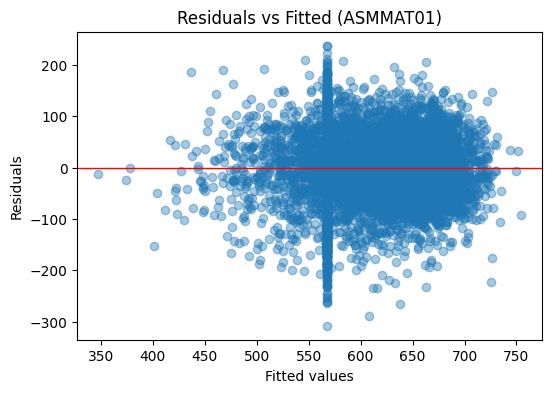

Ramsey RESET test:
<F test: F=9.724226852726, p=0.001826756741581798, df_denom=6.29e+03, df_num=1>


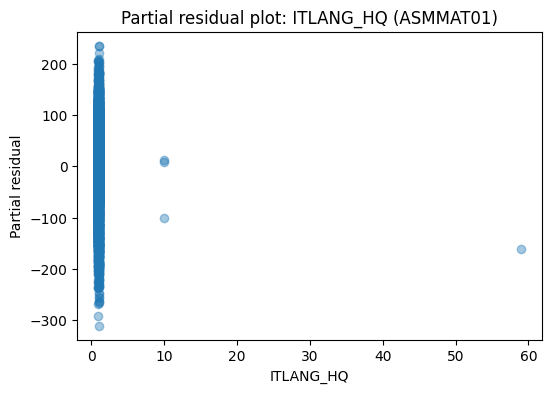


OLS Linearity Diagnostics for ASMMAT02


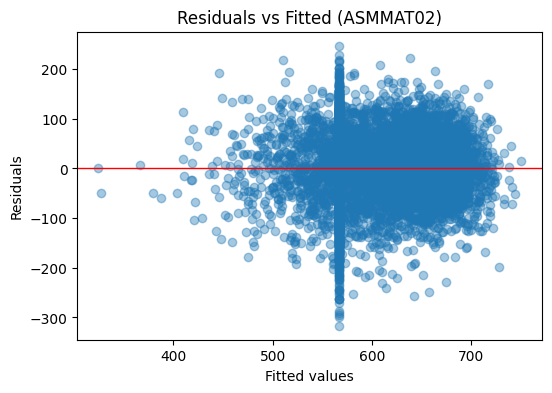

Ramsey RESET test:
<F test: F=4.896111100801667, p=0.0269530084057316, df_denom=6.29e+03, df_num=1>


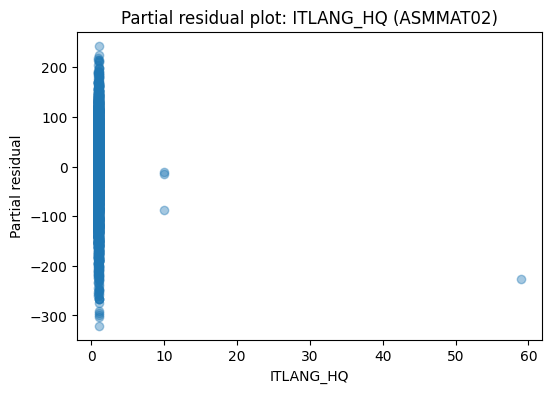


OLS Linearity Diagnostics for ASMMAT03


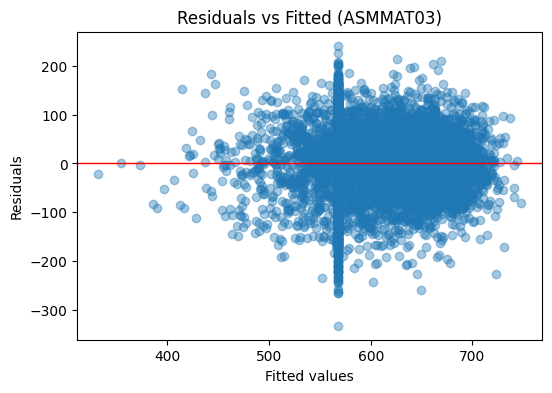

Ramsey RESET test:
<F test: F=6.155852013266601, p=0.013123728321623321, df_denom=6.29e+03, df_num=1>


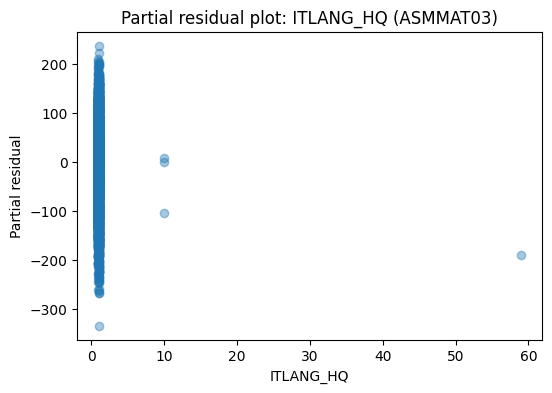


OLS Linearity Diagnostics for ASMMAT04


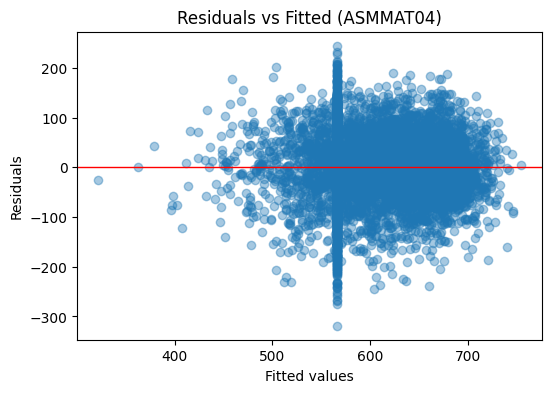

Ramsey RESET test:
<F test: F=4.579853582770475, p=0.03238831681305822, df_denom=6.29e+03, df_num=1>


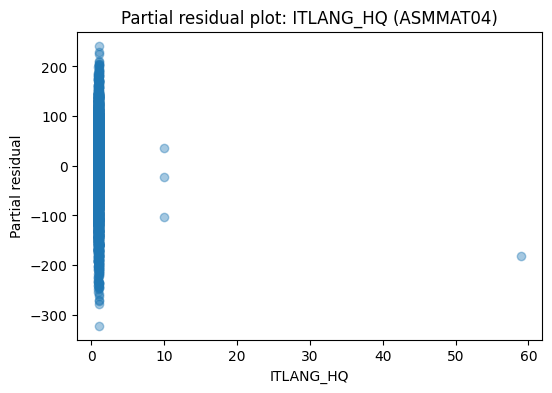


OLS Linearity Diagnostics for ASMMAT05


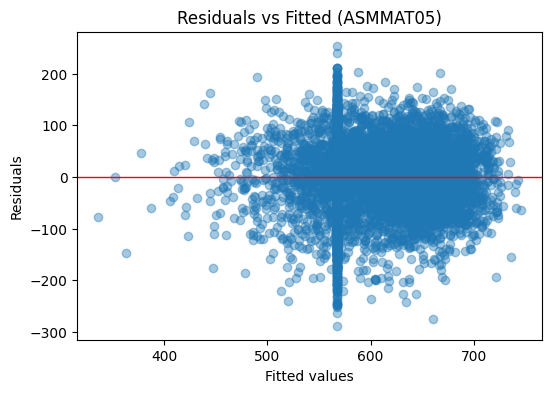

Ramsey RESET test:
<F test: F=4.990749967325932, p=0.025518151640051688, df_denom=6.29e+03, df_num=1>


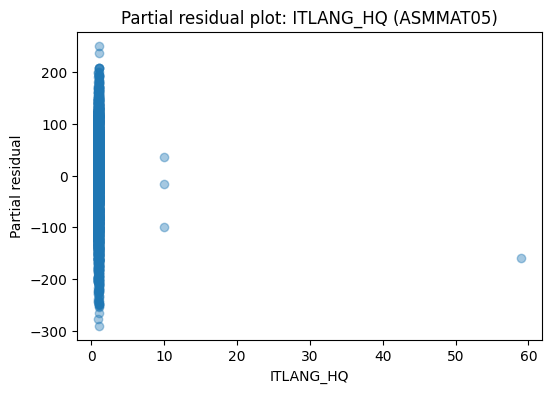

In [7]:
# =============================================================================
# Linearity Check
# =============================================================================

import statsmodels.api as sm
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt

for t in target:
    print(f"\n==============================")
    print(f"OLS Linearity Diagnostics for {t}")
    print(f"==============================")

    y_t = y[t]

    # Convert boolean columns to integer (0 or 1) to avoid statsmodels error
    X_KNN_imputed_numeric = X_KNN_imputed.copy()
    for col in X_KNN_imputed_numeric.select_dtypes(include='bool').columns:
        X_KNN_imputed_numeric[col] = X_KNN_imputed_numeric[col].astype(int)

    Xc = sm.add_constant(X_KNN_imputed_numeric)

    model = sm.OLS(y_t, Xc).fit()

    # 1) Residuals vs Fitted
    fitted = model.fittedvalues
    resid = model.resid

    plt.figure(figsize=(6,4))
    plt.scatter(fitted, resid, alpha=0.4)
    plt.axhline(0, color='red', lw=1)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted ({t})")
    plt.show()

    # 2) Ramsey RESET test
    reset = sms.linear_reset(model, power=2, use_f=True)
    print("Ramsey RESET test:")
    print(reset)

    # 3) Partial residual plot for one numeric feature
    feature = features_numeric[0]
    beta_j = model.params[feature]
    partial_resid = resid + beta_j * X_KNN_imputed_numeric[feature]
    plt.figure(figsize=(6,4))
    plt.scatter(X_KNN_imputed_numeric[feature], partial_resid, alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel("Partial residual")
    plt.title(f"Partial residual plot: {feature} ({t})")
    plt.show()


OLS Linearity Diagnostics for ASMMAT01


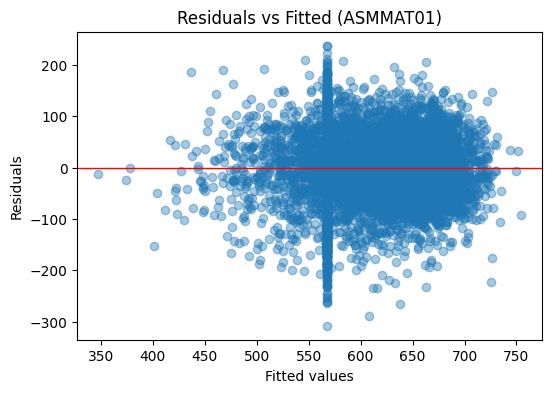

Ramsey RESET test:
<F test: F=9.724226852726, p=0.001826756741581798, df_denom=6.29e+03, df_num=1>


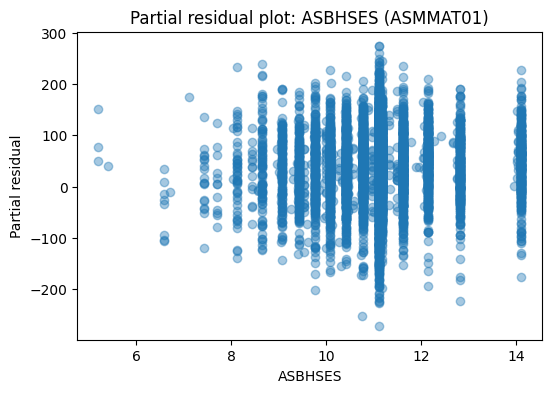


OLS Linearity Diagnostics for ASMMAT02


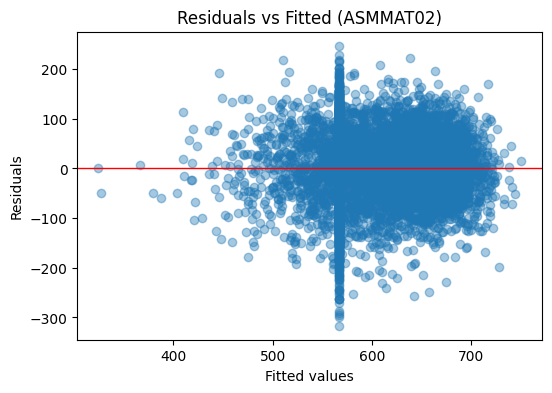

Ramsey RESET test:
<F test: F=4.896111100801667, p=0.0269530084057316, df_denom=6.29e+03, df_num=1>


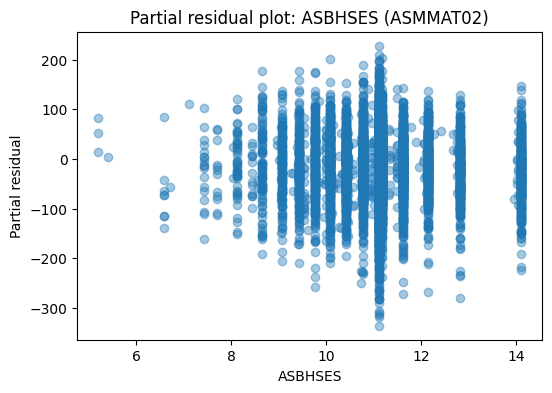


OLS Linearity Diagnostics for ASMMAT03


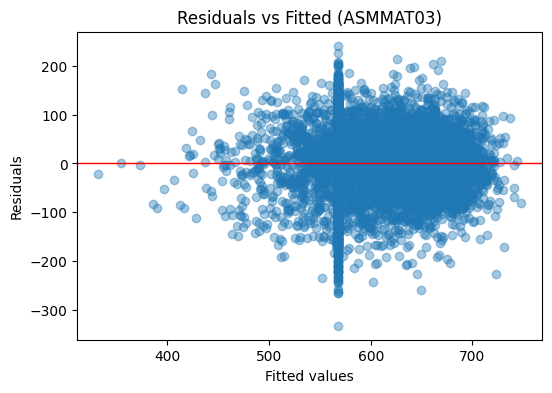

Ramsey RESET test:
<F test: F=6.155852013266601, p=0.013123728321623321, df_denom=6.29e+03, df_num=1>


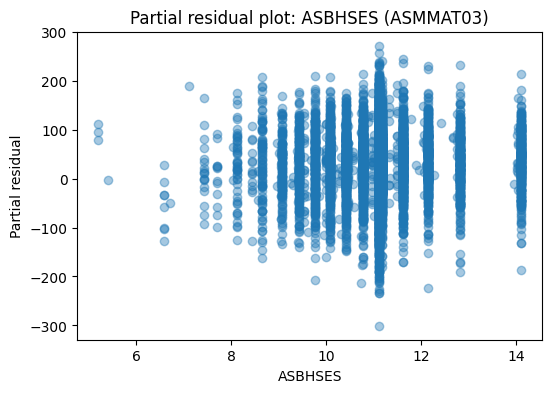


OLS Linearity Diagnostics for ASMMAT04


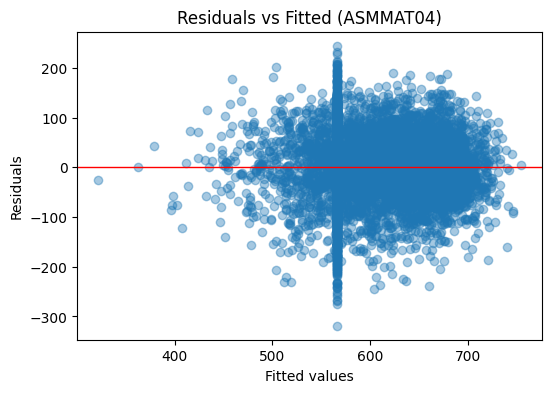

Ramsey RESET test:
<F test: F=4.579853582770475, p=0.03238831681305822, df_denom=6.29e+03, df_num=1>


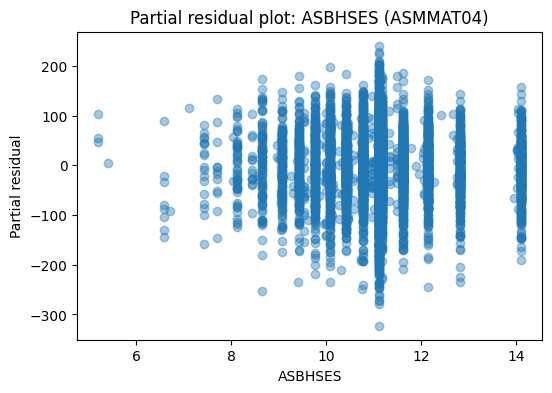


OLS Linearity Diagnostics for ASMMAT05


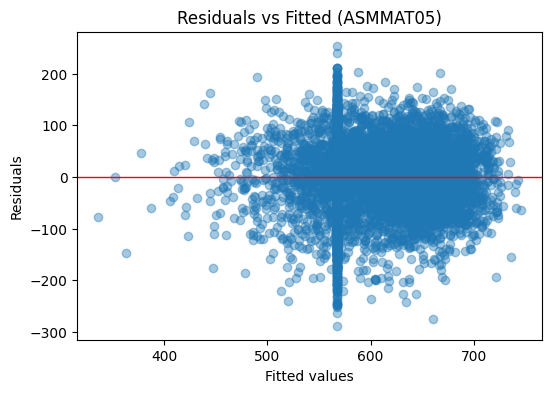

Ramsey RESET test:
<F test: F=4.990749967325932, p=0.025518151640051688, df_denom=6.29e+03, df_num=1>


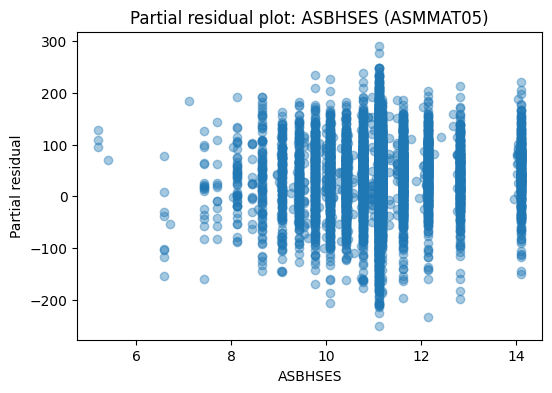

In [8]:
# =============================================================================
# Linearity Check
# =============================================================================

import statsmodels.api as sm
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt

for t in target:
    print(f"\n==============================")
    print(f"OLS Linearity Diagnostics for {t}")
    print(f"==============================")

    y_t = y[t]

    # Convert boolean columns to integer (0 or 1) to avoid statsmodels error
    X_KNN_imputed_numeric = X_KNN_imputed.copy()
    for col in X_KNN_imputed_numeric.select_dtypes(include='bool').columns:
        X_KNN_imputed_numeric[col] = X_KNN_imputed_numeric[col].astype(int)

    Xc = sm.add_constant(X_KNN_imputed_numeric)

    model = sm.OLS(y_t, Xc).fit()

    # 1) Residuals vs Fitted
    fitted = model.fittedvalues
    resid = model.resid

    plt.figure(figsize=(6,4))
    plt.scatter(fitted, resid, alpha=0.4)
    plt.axhline(0, color='red', lw=1)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted ({t})")
    plt.show()

    # 2) Ramsey RESET test
    reset = sms.linear_reset(model, power=2, use_f=True)
    print("Ramsey RESET test:")
    print(reset)

    # 3) Partial residual plot for one numeric feature
    feature = features_numeric[8]
    beta_j = model.params[feature]
    partial_resid = resid + beta_j * X_KNN_imputed_numeric[feature]
    plt.figure(figsize=(6,4))
    plt.scatter(X_KNN_imputed_numeric[feature], partial_resid, alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel("Partial residual")
    plt.title(f"Partial residual plot: {feature} ({t})")
    plt.show()

In [9]:
def run_model_pipeline(model_name, model, param_grid,
                       X_train, X_test, y_train, y_test, w_train):


    scoring = {
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        refit='rmse',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    if model_name == "ElasticNet":
      grid.fit(X_train, y_train)
    else:
      grid.fit(X_train, y_train, sample_weight=w_train)

    best_model = grid.best_estimator_
    best_idx = grid.best_index_

    # Train
    train_pred = best_model.predict(X_train)
    train_rmse = np.sqrt(MSE(y_train, train_pred))
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)

    # Validation
    cv_rmse = -grid.cv_results_['mean_test_rmse'][best_idx]
    cv_mae  = -grid.cv_results_['mean_test_mae'][best_idx]
    cv_r2   =  grid.cv_results_['mean_test_r2'][best_idx]

    # Test
    test_pred = best_model.predict(X_test)
    test_rmse = np.sqrt(MSE(y_test, test_pred))
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    # Feature importance
    #importances = pd.Series(best_model.feature_importances_, index=X_train.columns)

    if hasattr(best_model, "feature_importances_"):
      importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    else:
      importances = pd.Series(best_model.coef_, index=X_train.columns)

    return {
        "results": {
            "Train": (train_rmse, train_mae, train_r2),
            "Validation": (cv_rmse, cv_mae, cv_r2),
            "Test": (test_rmse, test_mae, test_r2)
        },
        "best_params": grid.best_params_,
        "feature_importances": importances
    }


In [10]:
rf_grid = {
    'n_estimators': [300, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 6, 8, 12],
    'min_samples_split': [5, 20, 40],
    'min_samples_leaf': [5, 10, 20],
    'max_samples': [0.8, 1, 5]
}

xgb_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.6, 0.7, 0.8],
    'max_depth': [3, 4, 5],
    'colsample_bytree': [0.5, 0.6, 0.8],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
    'min_child_weight': [5, 10]
}

lgbm_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 5],
    'num_leaves': [7, 15],
    'min_data_in_leaf': [20,100],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}


In [11]:
targets = ["ASMMAT01","ASMMAT02","ASMMAT03","ASMMAT04","ASMMAT05"]

all_results = []
all_best_params = {}
all_feature_importances = {}

SEED = 1

for target in targets:
    print("\n==============================")
    print("Running PV:", target)
    print("==============================")

    y = df[target]

    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X_KNN_imputed, y, w, test_size=0.2, random_state=SEED
    )

    # Standardization
    scaler = StandardScaler()

    numeric_cols = features_numeric

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    all_best_params[target] = {}
    all_feature_importances[target] = {}

    # RF
    rf_out = run_model_pipeline(
        "RandomForest",
        RandomForestRegressor(random_state=SEED),
        rf_grid,
        X_train_scaled, X_test_scaled, y_train, y_test, w_train
    )
    for split, (rmse, mae, r2) in rf_out["results"].items():
        all_results.append([target,"RandomForest",split,rmse,mae,r2])
    all_best_params[target]["RandomForest"] = rf_out["best_params"]
    all_feature_importances[target]["RandomForest"] = rf_out["feature_importances"]

    # XGB
    xgb_out = run_model_pipeline(
        "XGBoost",
        XGBRegressor(objective='reg:squarederror', random_state=SEED, eval_metric="rmse"),
        xgb_grid,
        X_train_scaled, X_test_scaled, y_train, y_test, w_train
    )
    for split, (rmse, mae, r2) in xgb_out["results"].items():
        all_results.append([target,"XGBoost",split,rmse,mae,r2])
    all_best_params[target]["XGBoost"] = xgb_out["best_params"]
    all_feature_importances[target]["XGBoost"] = xgb_out["feature_importances"]

    # LGBM
    lgbm_out = run_model_pipeline(
        "LightGBM",
        LGBMRegressor(objective='regression', random_state=SEED),
        lgbm_grid,
        X_train_scaled, X_test_scaled, y_train, y_test, w_train
    )
    for split, (rmse, mae, r2) in lgbm_out["results"].items():
        all_results.append([target,"LightGBM",split,rmse,mae,r2])
    all_best_params[target]["LightGBM"] = lgbm_out["best_params"]
    all_feature_importances[target]["LightGBM"] = lgbm_out["feature_importances"]


Running PV: ASMMAT01
Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

In [20]:
# print("NaN in X_train_scaled:", X_train_scaled.isna().sum().sum())
# print("NaN in X_test_scaled:", X_test_scaled.isna().sum().sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [21]:
# print("Before scaling NaN:", X_train.isna().sum().sum())
# print("After scaling NaN:", X_train_scaled.isna().sum().sum())
# print(X_train_scaled.isna().sum().sort_values(ascending=False).head(20))


Before scaling NaN: 0
After scaling NaN: 0
ITLANG_HQ      0
LCID_HQ        0
ASBHELA        0
ASBHENA        0
ASBHELN        0
ASBHELT        0
ASBHENT        0
ASBHLNT        0
ASBHPSP        0
ASBHSES        0
ASBH01A_2.0    0
ASBH01A_3.0    0
ASBH01B_2.0    0
ASBH01B_3.0    0
ASBH01C_2.0    0
ASBH01C_3.0    0
ASBH01D_2.0    0
ASBH01D_3.0    0
ASBH01E_2.0    0
ASBH01E_3.0    0
dtype: int64


In [22]:
# print(X_train_scaled.isna().sum().sort_values(ascending=False).head(20))

ITLANG_HQ      0
LCID_HQ        0
ASBHELA        0
ASBHENA        0
ASBHELN        0
ASBHELT        0
ASBHENT        0
ASBHLNT        0
ASBHPSP        0
ASBHSES        0
ASBH01A_2.0    0
ASBH01A_3.0    0
ASBH01B_2.0    0
ASBH01B_3.0    0
ASBH01C_2.0    0
ASBH01C_3.0    0
ASBH01D_2.0    0
ASBH01D_3.0    0
ASBH01E_2.0    0
ASBH01E_3.0    0
dtype: int64


In [13]:
results_df = pd.DataFrame(all_results, columns=["PV","Model","Split","RMSE","MAE","R2"])
print("\n=== Comprehensive Results Across PVs and Models ===")
print(results_df.round(4).to_string(index=False))

print("\n=== Best Parameters per PV ===")
for pv in all_best_params:
    print("\nPV:", pv)
    for model in all_best_params[pv]:
        print(model, ":", all_best_params[pv][model])

print("\n=== Feature Importances per PV (Top 10) ===")
for pv in all_feature_importances:
    print("\nPV:", pv)
    for model in all_feature_importances[pv]:
        print("\n", model)
        print(all_feature_importances[pv][model].sort_values(ascending=False).head(10))



=== Comprehensive Results Across PVs and Models ===
Empty DataFrame
Columns: [PV, Model, Split, RMSE, MAE, R2]
Index: []

=== Best Parameters per PV ===

PV: ASMMAT01

=== Feature Importances per PV (Top 10) ===

PV: ASMMAT01


In [14]:
for pv in all_feature_importances:
    print(f"\n=== Plotting Feature Importance for {pv} ===")

    for model in all_feature_importances[pv]:

        fi = all_feature_importances[pv][model].sort_values(ascending=False).head(10)

        plt.figure(figsize=(8,6))
        fi.plot(kind='barh')
        plt.title(f"Top 10 Feature Importance\nPV: {pv} | Model: {model}")
        plt.gca().invert_yaxis()
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()


=== Plotting Feature Importance for ASMMAT01 ===


In [15]:
# ==============================
# Summary: mean & std by subset
# ==============================

# all_results -> DataFrame
results_df = pd.DataFrame(
    all_results,
    columns=["PV", "Model", "Split", "RMSE", "MAE", "R2"]
)

# mean & std for each PV-Model-Split
summary_mean_std = (
    results_df
    .groupby(["PV", "Model", "Split"], as_index=False)
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
)

# ordering
split_order = pd.CategoricalDtype(["Train", "Validation", "Test"], ordered=True)
summary_mean_std["Split"] = summary_mean_std["Split"].astype(split_order)
summary_mean_std = summary_mean_std.sort_values(["PV", "Model", "Split"]).reset_index(drop=True)

print(summary_mean_std)

Empty DataFrame
Columns: [PV, Model, Split, RMSE_mean, RMSE_std, MAE_mean, MAE_std, R2_mean, R2_std]
Index: []


In [ ]:
# Compute standard deviation for training and test targets
std_train = statistics.stdev(y_train)
std_test = statistics.stdev(y_test)

print("Standard deviation of y_train:", round(std_train, 4))
print("Standard deviation of y_test:", round(std_test, 4))

# Compare RMSE to SD
rmse_rf_test = 74.5594
rmse_xgbm_test = 73.6696
rmse_lgbm_test = 73.6456
print("RF Test RMSE / SD(y_test):", rmse_rf_test / std_test)
print("XGBoost Test RMSE / SD(y_test):", rmse_xgbm_test / std_test)
print("LightGBM Test RMSE / SD(y_test):", rmse_lgbm_test / std_test)

Standard deviation of y_train: 88.4999
Standard deviation of y_test: 90.0201
RF Test RMSE / SD(y_test): 0.8282526533310287
XGBoost Test RMSE / SD(y_test): 0.8183681959596718
LightGBM Test RMSE / SD(y_test): 0.8181015888828989


In [31]:
# Performing Shapiro-Wilk normality tests
from scipy.stats import shapiro, levene

# -----------------------------
data = {
    "RandomForest": {
        "train": [58.6656, 59.3924, 58.8865, 58.9950, 59.5945],
        "val":   [73.6488, 74.5676, 73.3869, 73.7709, 74.6113],
        "test":  [74.5374, 75.0382, 73.3846, 73.9678, 74.5736]
    },
    "XGBoost": {
        "train": [62.6448, 48.2234, 62.6000, 62.7255, 63.4241],
        "val":   [73.0979, 73.9195, 72.7277, 73.1348, 73.9907],
        "test":  [73.5895, 74.6267, 73.0577, 73.3276, 74.0915]
    },
    "LightGBM": {
        "train": [66.7810, 67.4631, 66.6298, 66.9910, 67.5799],
        "val":   [73.3196, 74.1732, 73.0644, 73.5132, 74.1062],
        "test":  [74.0388, 74.8879, 73.1237, 73.7096, 74.2211]
    },
    "ElasticNet": {
        "train": [71.0355, 71.4159, 70.3252, 70.4514, 71.2477],
        "val":   [72.8054, 73.7567, 72.5088, 72.6588, 73.5798],
        "test":  [73.4005, 73.9630, 72.0326, 72.5546, 73.1229]
    }
}

# -----------------------------
# run Shapiro for each model
# -----------------------------
def check_normality(metric):
    print(f"\n=== Shapiro–Wilk Normality Test for {metric.upper()} ===")
    for model, metrics in data.items():
        stat, p = shapiro(metrics[metric])
        print(f"{model:12s}  p = {p:.4f}")

# -----------------------------
# run Levene for variance homogeneity
# -----------------------------
def check_variance(metric):
    print(f"\n=== Levene’s Test for {metric.upper()} (Homogeneity of Variance) ===")
    groups = [metrics[metric] for metrics in data.values()]
    stat, p = levene(*groups)
    print(f"Levene p = {p:.4f}")

# -----------------------------
# Run tests for train / val / test
# -----------------------------
for metric in ["train", "val", "test"]:
    check_normality(metric)
    check_variance(metric)


=== Shapiro–Wilk Normality Test for TRAIN ===
RandomForest  p = 0.7433
XGBoost       p = 0.0006
LightGBM      p = 0.4692
ElasticNet    p = 0.3974

=== Levene’s Test for TRAIN (Homogeneity of Variance) ===
Levene p = 0.4526

=== Shapiro–Wilk Normality Test for VAL ===
RandomForest  p = 0.2267
XGBoost       p = 0.2925
LightGBM      p = 0.4248
ElasticNet    p = 0.2305

=== Levene’s Test for VAL (Homogeneity of Variance) ===
Levene p = 0.9954

=== Shapiro–Wilk Normality Test for TEST ===
RandomForest  p = 0.7698
XGBoost       p = 0.8110
LightGBM      p = 0.9900
ElasticNet    p = 0.9765

=== Levene’s Test for TEST (Homogeneity of Variance) ===
Levene p = 0.9768


In [29]:
!pip install scikit-posthocs

from scipy.stats import kruskal
import scikit_posthocs as sp
import pandas as pd

# Prepare data
models = ["RandomForest", "XGBoost", "LightGBM", "ElasticNet"]
test_rmse = [
    data["RandomForest"]["test"],
    data["XGBoost"]["test"],
    data["LightGBM"]["test"],
    data["ElasticNet"]["test"]
]

# 1. Kruskal–Wallis test
stat, p = kruskal(*test_rmse)
print("Kruskal–Wallis H =", stat, ", p =", p)

# 2. Dunn’s post-hoc test
df = pd.DataFrame({
    "RMSE": data["RandomForest"]["test"]
            + data["XGBoost"]["test"]
            + data["LightGBM"]["test"]
            + data["ElasticNet"]["test"],
    "Model": ["RF"]*5 + ["XGB"]*5 + ["LGBM"]*5 + ["EN"]*5
})

dunn = sp.posthoc_dunn(df, val_col="RMSE", group_col="Model", p_adjust="bonferroni")
print(dunn)


Kruskal–Wallis H = 6.7371428571428424 , p = 0.08076497485129056
            EN      LGBM        RF  XGB
EN    1.000000  0.325916  0.083641  1.0
LGBM  0.325916  1.000000  1.000000  1.0
RF    0.083641  1.000000  1.000000  1.0
XGB   1.000000  1.000000  1.000000  1.0
